# 04 · 子圖與版面：subplots 與 GridSpec

回到第 01 課的心智模型：**一張 Figure 可以裝很多個 Axes**。這課就來把多個 Axes 排得整齊好看。

> 💡 可執行 notebook，`Shift+Enter` 跑每一格。

## 學習目標

- 用 `plt.subplots(列, 欄)` 切出規則的子圖網格
- 用 `sharex` / `sharey` 共用座標軸
- 用 `GridSpec` 做**不等大小**的版面
- 用 `constrained_layout` 自動排好間距，不再重疊

## 1. 規則網格：subplots(列, 欄)

回傳的 `axes` 是一個 2D 陣列，`axes[列][欄]` 取出每一格。

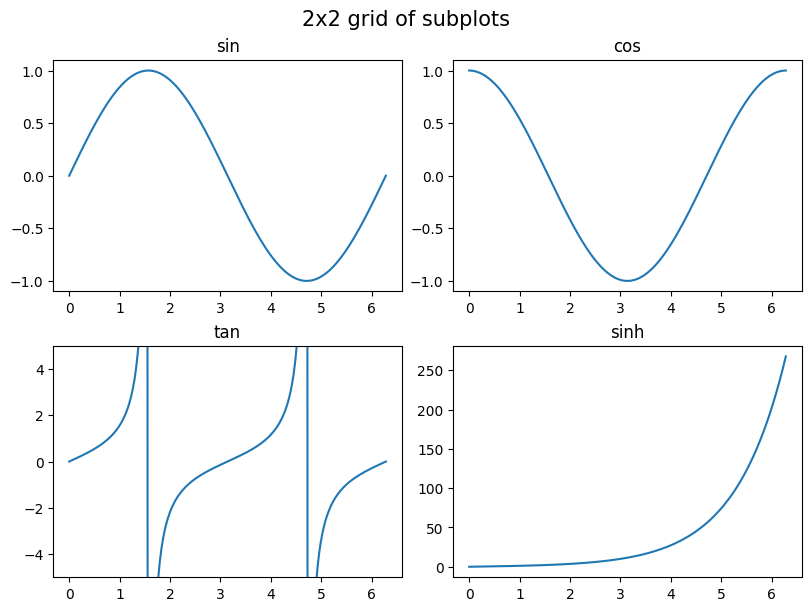

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 200)
funcs = [("sin", np.sin), ("cos", np.cos), ("tan", np.tan), ("sinh", np.sinh)]

fig, axes = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)

# axes 是 2x2 陣列；用 .flat 攤平成一維方便逐格處理
for ax, (name, f) in zip(axes.flat, funcs):
    ax.plot(x, f(x), color="tab:blue")
    ax.set_title(name)

axes[1][0].set_ylim(-5, 5)   # tan 會爆衝，手動限制 y 範圍
fig.suptitle("2x2 grid of subplots", fontsize=15)
plt.show()

💡 `constrained_layout=True` 會自動調整子圖間距，避免標題、軸標籤互相重疊。沒加它的話，常需要手動 `fig.tight_layout()`。

## 2. 共用座標軸：sharex / sharey

當幾個子圖的尺度一致時，共用軸能省掉重複刻度、讓比較更直接。

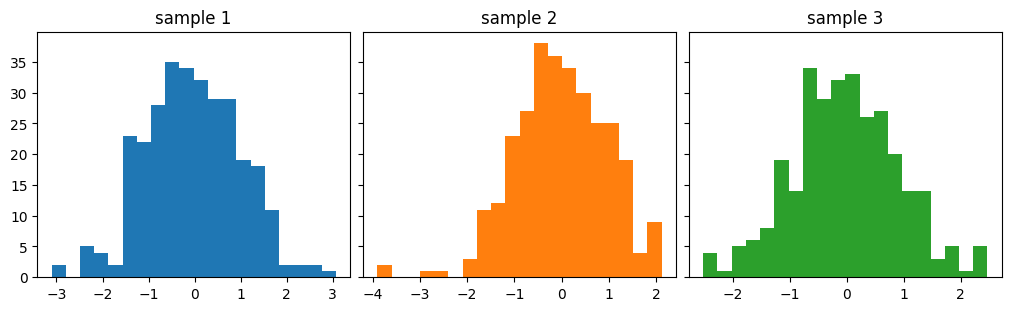

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True, constrained_layout=True)

rng = np.random.default_rng(0)
for i, ax in enumerate(axes):
    ax.hist(rng.normal(0, 1, 300), bins=20, color=f"C{i}")
    ax.set_title(f"sample {i + 1}")

# 因為 sharey=True，只有最左邊那格顯示 y 刻度
plt.show()

## 3. 不等大小的版面：GridSpec

規則網格不夠用時（例如「上面一張寬圖、下面兩張小圖」），用 `GridSpec` 在一個 N×M 的格子上自由分配。

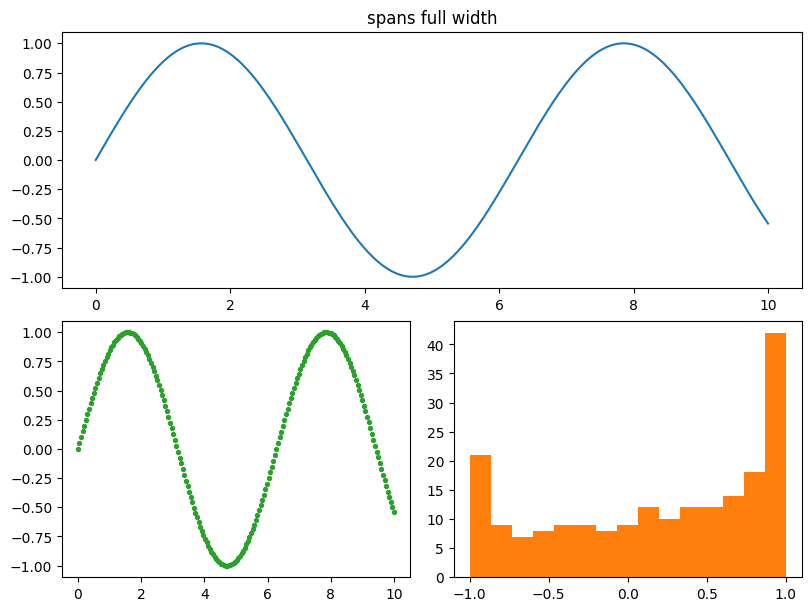

In [3]:
x = np.linspace(0, 10, 200)

fig = plt.figure(figsize=(8, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2)            # 想像成 2x2 的格子

ax_top = fig.add_subplot(gs[0, :])     # 第 0 列、跨兩欄 → 一張寬圖
ax_bl = fig.add_subplot(gs[1, 0])      # 第 1 列左
ax_br = fig.add_subplot(gs[1, 1])      # 第 1 列右

ax_top.plot(x, np.sin(x), color="tab:blue")
ax_top.set_title("spans full width")
ax_bl.scatter(x, np.sin(x), s=8, color="tab:green")
ax_br.hist(np.sin(x), bins=15, color="tab:orange")
plt.show()

`gs[0, :]` 的 `:` 代表「整列所有欄」，所以上方那張圖橫跨整個寬度。改成 `gs[:, 0]` 就會變成「左側整欄」——試試看。

## 小結

- 規則網格用 `plt.subplots(列, 欄)`，`axes` 是陣列、`.flat` 方便逐格處理。
- 尺度一致時用 `sharex` / `sharey` 共用軸。
- 不等大小版面用 `fig.add_gridspec()` + `fig.add_subplot(gs[...])`。
- 養成加 `constrained_layout=True` 的習慣，省掉重疊問題。

## 練習

1. 做一個 3×1 的版面，分別畫某檔股票的「收盤價折線」「成交量長條」「日報酬直方圖」，並 `sharex`（前兩張）。
2. 用 GridSpec 做「左側一張大圖、右側上下兩張小圖」的儀表板版面。

下一課：把座標軸玩熟——對數軸、雙 y 軸、箭頭標註與自訂刻度。